In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, RocCurveDisplay

In [28]:
titanic_df = pd.read_csv("Titanic.csv")

titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())
titanic_df["Sex"] = titanic_df["Sex"].map({"male": 0, "female": 1})

X = titanic_df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]]
y = 1 - titanic_df["Survived"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [29]:
model1 = LogisticRegression(max_iter=1000)

model1_params = {
    "penalty": ["l1", "l2"],
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear"]
}

model1_grid = GridSearchCV(model1, model1_params, cv=5, scoring="accuracy")
model1_grid.fit(X_train, y_train)

best_model1 = model1_grid.best_estimator_

print("Best Parameters:", model1_grid.best_params_)
print("Best Cross-Validation Accuracy:", model1_grid.best_score_)

Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.7962868117797696


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

In [30]:
best_penalty = model1_grid.best_params_["penalty"]

print("Best Penalty:", best_penalty)

Best Penalty: l2


The best penalty was L2. This means that the model performed the best when all the features were kept in the model but their coefficients were reduced to prevent overfitting. What L2 regularization does it that it shrinks the coefficients without setting them to zero, which means that all the Titanic features contributed something useful / some useful information related to predicting the deaths. 

In [31]:
best_c = model1_grid.best_params_["C"]

print("Best C:", best_c)

Best C: 0.1


The best C value was 0.1. This means that the model performed the best with a pretty moderate amount of regularization. A smaller C value corresponds to a stronger regularization, which helps prevent overfitting. The value of 0.1 suggests that limiting the model's capabilities slightly helped improve its ability to generalize new Titanic data. 

In [32]:
model1_predictions = best_model1.predict(X_test)

model1_probabilities = best_model1.predict_proba(X_test)[:, 1]

In [33]:
model1_accuracy = accuracy_score(
    y_test,
    model1_predictions
)

model1_precision = precision_score(
    y_test,
    model1_predictions
)

model1_recall = recall_score(
    y_test,
    model1_predictions
)

model1_auc = roc_auc_score(
    y_test,
    model1_probabilities
)

print("Accuracy:", model1_accuracy)
print("Precision:", model1_precision)
print("Recall:", model1_recall)
print("AUC:", model1_auc)

Accuracy: 0.7932960893854749
Precision: 0.8035714285714286
Recall: 0.8571428571428571
AUC: 0.8785070785070785


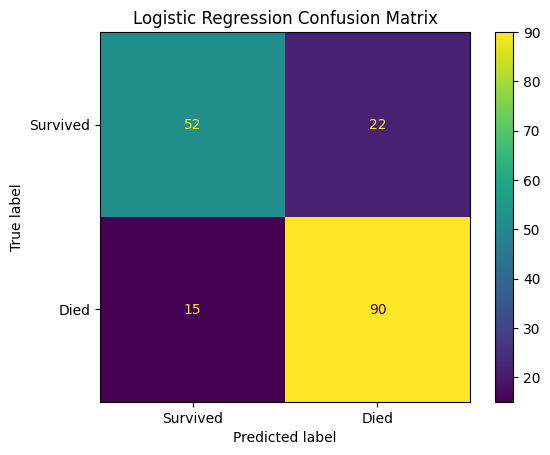

In [34]:
conf_matrix = confusion_matrix(
    y_test,
    model1_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=["Survived", "Died"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

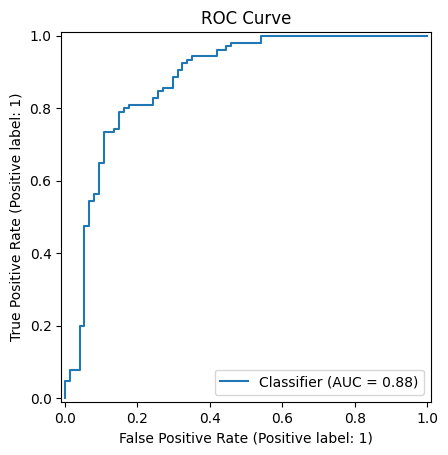

In [35]:
RocCurveDisplay.from_predictions(
    y_test,
    model1_probabilities
)

plt.title("ROC Curve")
plt.show()

I think that Recall is the most important for death prediction because it would measure how many of the deaths the model ACTUALLY got right. Missing someone who died would be the most serious error in this scenario so recall is pretty dang important. 

I think linear regression isn't really appropriate for this problem since it's for continuous numerical values wheras death vs survival is more like a classfication problem with two categories. Logistic regression is more appropriate since it predicts probabilities between 0 and 1 + it's a classifier. 

In [36]:
spotify_df = pd.read_csv("Spotify2019.csv")

spotify_df.columns

Index(['id', 'name', 'artists', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature'],
      dtype='str')

In [37]:
X = spotify_df[[
    "energy",
    "valence",
    "tempo"
]]

y = spotify_df["danceability"]

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

I chose tempo, energy, and valance to predict danceability. The variables seem like they would be connected to how energetic and upbeat a song might feel which should influence danceability pretty strongly. 

In [39]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [40]:
lasso_model = Lasso(max_iter=10000)

lasso_params = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

lasso_grid = GridSearchCV(
    lasso_model,
    lasso_params,
    cv=5,
    scoring="neg_mean_squared_error"
)

lasso_grid.fit(X_train, y_train)

best_lasso_model = lasso_grid.best_estimator_

print("Best Lasso Parameters:", lasso_grid.best_params_)
print("Best Lasso CV Score:", lasso_grid.best_score_)

Best Lasso Parameters: {'alpha': 0.001}
Best Lasso CV Score: -0.016494638778516


In [41]:
lasso_predictions = best_lasso_model.predict(X_test)

lasso_mse = mean_squared_error(
    y_test,
    lasso_predictions
)

lasso_rmse = lasso_mse ** 0.5

lasso_r2 = r2_score(
    y_test,
    lasso_predictions
)

print("Lasso MSE:", lasso_mse)
print("Lasso RMSE:", lasso_rmse)
print("Lasso R2:", lasso_r2)
print("Lasso Coefficients:", best_lasso_model.coef_)

Lasso MSE: 0.0209016010582464
Lasso RMSE: 0.14457386021769772
Lasso R2: -0.5955225782163267
Lasso Coefficients: [0.02783897 0.04977861 0.01934975]


The best "alpha" parameter for the Lasso regression was 0.001, which means that the model performed best with very light amounts of regularization. The R2 value was around 0.59 which means that the model explained about 59% of the variation in daceability. The RMSE was about 0.145 which means that the predictions of the model were off by about that much on average.  

In [42]:
from sklearn.linear_model import Ridge

In [43]:
ridge_model = Ridge()

ridge_params = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_model,
    ridge_params,
    cv=5,
    scoring="neg_mean_squared_error"
)

ridge_grid.fit(X_train, y_train)

best_ridge_model = ridge_grid.best_estimator_

print("Best Ridge Parameters:", ridge_grid.best_params_)
print("Best Ridge CV Score:", ridge_grid.best_score_)

Best Ridge Parameters: {'alpha': 10}
Best Ridge CV Score: -0.015728749618505337


In [44]:
ridge_predictions = best_ridge_model.predict(X_test)

ridge_mse = mean_squared_error(
    y_test,
    ridge_predictions
)

ridge_rmse = ridge_mse ** 0.5

ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)

print("Ridge MSE:", ridge_mse)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R2:", ridge_r2)
print("Ridge Coefficients:", best_ridge_model.coef_)

Ridge MSE: 0.020024544147212674
Ridge RMSE: 0.1415081062950553
Ridge R2: -0.5285724866881527
Ridge Coefficients: [0.02766053 0.04081714 0.01582995]


The best "alpha" parameter for Ridge regression was 10, which means that the model performed best with a stronger regularization. Ridge uses L2 regularization which shrinks the coefficients to reduce overfitting but still keeps all the predictor variables. The R2 value was abt 0.52 which means that the model explains around 52% of the variation in danceability. RMSE was about 0.142 which means that the model's predictions were off by about that much on average.  

WORSHEET 9 BEGINS HERE

1. Not explicitly labeled

2. K-means clustering and PCA (Principle components analysis) 

3. A centroid is the center point of a cluster in K-means. It's the average of all the points assigned to that cluster. 

4.  Under line 7, the blue points represent the data points and the stars represent the centroids

5. For each point you calculate how far it is from the centroid then assign it to the centroid with the smallest distance.

6.  Centroids: NumPy array, X: NumPy array, np.square: NumPy function, min_distance: integer at first then used like a number, idx: NumPy array

7. The purpose of line 9 is to define the function that finds the closest centroid for every data point

8. The difference between the plot in line 7 and the plot in line 10 is that the first plot shows raw data and initial centroid locations whereas the second one shows the points GROUPED by cluster assignments. 

9. The equation calculates the new location of each centroid by averaging all the datapoints currently assigned to that cluster. Basically how the centroid moves to the center of the cluster/group after each round. 

10. The purpose of lines 17-24 is to run the entire K-Means process over and over

Assigns points to nearest centroids
Recalculates the centroid locations
Saves the history of the centroids over each iteration
Returns the final cluster assignments
11. from sklearn.cluster import KMeans

      km1 = KMeans(3)

      km1.fit(X1)

12. n_clusters --> how many clusters you want

       n_init --> how many times K-Means runs with different starting points

       tol --> stops the algorithm is centroid movement gets very small

       max_iter --> maximum number of update steps for each run

       

13.

The image is being turned into a big list of pixels and each pixel is a three number RGB value
K-means actually reduces the color by replacing all the similar colors with a smaller set of centroid colors
Ends up compressing the image since we now keep a very limited color palette
14. X3 in line 39 is a NumPy array 

15. mean normalization 

16. I've already done vector stuff in Linear Algebra but there's some good stuff on Khan Academy

17. performs PCA

Computes the mean
Normalizes the data
computes a covariance matrix
runs SVD to get principal components of variation in the data 
18. Since most of the data exists along one direction, PCA figures out that direction then uses it to summarize the data in a more simple way.

19. I think it moves the original data down into a lower dimension and then rebuilds the graph? 

20. 

from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
pca_result = pca.fit_transform(X3)
21.  I think it came from an earlier cell where the dataset was loaded since X3 is the data being put into PCA

n components = 2 means keep only 2 principal components

22. means that the PCA output has 50 rows and 2 columns, so there's 50 data points and each one is being described using 2 principal components. Variation per component means that the first principal component captured around 87% of the data, then the second around 13% and together they capture 100%. 

 

23. Read it! :) 

24.

from sklearn.datasets import load_sample_image
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

china = load_sample_image("china.jpg")

plt.imshow(china)
plt.axis("off")
plt.show()

china_pixels = china.reshape(-1, 3)

kmeans = KMeans(n_clusters=16, random_state=42, n_init=10)
kmeans.fit(china_pixels)

compressed_pixels = kmeans.cluster_centers_[kmeans.labels_]

compressed_image = compressed_pixels.reshape(china.shape)
compressed_image = compressed_image.astype("uint8")

plt.imshow(compressed_image)
plt.axis("off")
plt.show()
 

25. Didn't have time for the optional bonus question :) 